In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Notice the 'r' before the opening quote
file_path = r"D:\Agri_Yield\backend\datasets\crop_yield_dataset2.csv"
df = pd.read_csv(file_path, parse_dates=["Date"])
df = pd.read_csv(file_path, parse_dates=["Date"])
df['Date'] = pd.to_datetime(df['Date'])
df.set_index("Date", inplace=True)
df = df.select_dtypes(include="number")
df = df.groupby(df.index).mean()
df = df.asfreq("D")
df = df.interpolate(method="time")
print("Data successfully loaded and preprocessed.")
df.head()

Data successfully loaded and preprocessed.


,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
Date,,,,,,,,,
2014-01-01,6.275,15.994309,79.994742,8.163837,64.55,51.60,40.50,37.073799,35.920833
2014-01-02,6.575,15.639907,79.998234,9.669001,67.00,54.05,43.15,34.636737,32.750000
2014-01-03,6.450,15.156596,79.028168,11.052915,66.50,53.30,42.35,22.107670,41.579167
2014-01-04,6.950,15.026332,79.479529,10.162655,68.70,55.80,44.75,28.197627,40.587500
2014-01-05,6.400,13.828252,80.000000,10.523809,68.45,55.65,45.00,26.062550,51.362500


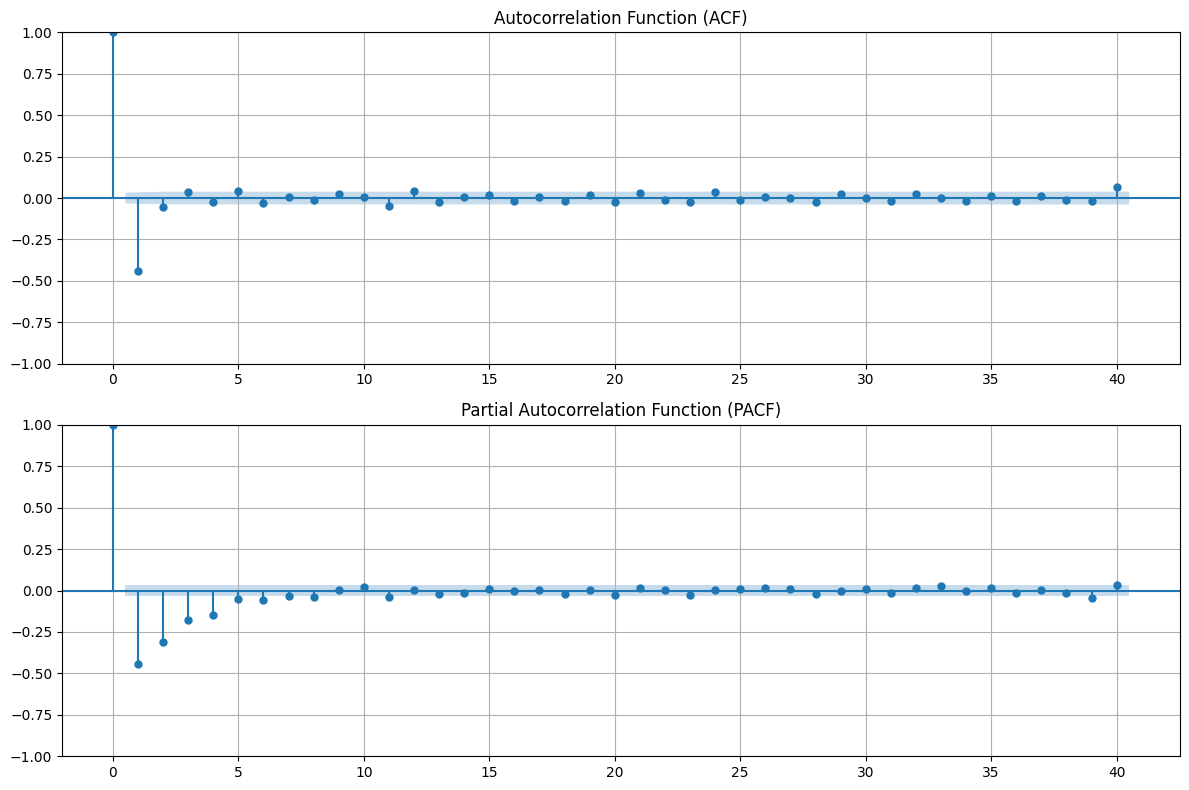

In [6]:
series = df["Crop_Yield"]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(series.diff().dropna(), lags=40, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')
ax1.grid(True)
plot_pacf(series.diff().dropna(), lags=40, ax=ax2, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')
ax2.grid(True)
plt.tight_layout()
plt.show()

In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
print("--- Fitting Univariate SARIMAX (SARIMA) Model ---")
series = df["Crop_Yield"]
model_uni = SARIMAX(series, 
                    order=(1, 1, 1), 
                    seasonal_order=(1, 1, 1, 7))
fit_uni = model_uni.fit(disp=False)
forecast_steps = 10
forecast_obj_uni = fit_uni.get_forecast(steps=forecast_steps)
forecast_mean_uni = forecast_obj_uni.predicted_mean
forecast_ci_uni = forecast_obj_uni.conf_int()
print(f"\nUnivariate SARIMAX Forecast (next {forecast_steps} days):")
print(forecast_mean_uni)

--- Fitting Univariate SARIMAX (SARIMA) Model ---

Univariate SARIMAX Forecast (next 10 days):
2024-01-01    23.611431
2024-01-02    24.113223
2024-01-03    23.470084
2024-01-04    24.183965
2024-01-05    23.742343
2024-01-06    23.801626
2024-01-07    23.364694
2024-01-08    23.774630
2024-01-09    24.107700
2024-01-10    23.398954
Freq: D, Name: predicted_mean, dtype: float64


In [10]:
print("\n--- Fitting Multivariate SARIMAX Model ---")
target = df["Crop_Yield"]
exog = df.drop(columns=["Crop_Yield"])
model_multi = SARIMAX(target, exog=exog, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
fit_multi = model_multi.fit(disp=False)
forecast_steps = 10
future_exog = exog.iloc[-forecast_steps:]
forecast_obj_multi = fit_multi.get_forecast(steps=forecast_steps, exog=future_exog)
forecast_mean_multi = forecast_obj_multi.predicted_mean
forecast_ci_multi = forecast_obj_multi.conf_int()
print(f"\nMultivariate SARIMAX Forecast (next {forecast_steps} days):")
print(forecast_mean_multi)


--- Fitting Multivariate SARIMAX Model ---

Multivariate SARIMAX Forecast (next 10 days):
2024-01-01    23.695535
2024-01-02    21.513660
2024-01-03    21.285676
2024-01-04    29.845995
2024-01-05    26.345114
2024-01-06    39.959362
2024-01-07    24.498626
2024-01-08    29.541818
2024-01-09    21.577416
2024-01-10     7.975332
Freq: D, Name: predicted_mean, dtype: float64


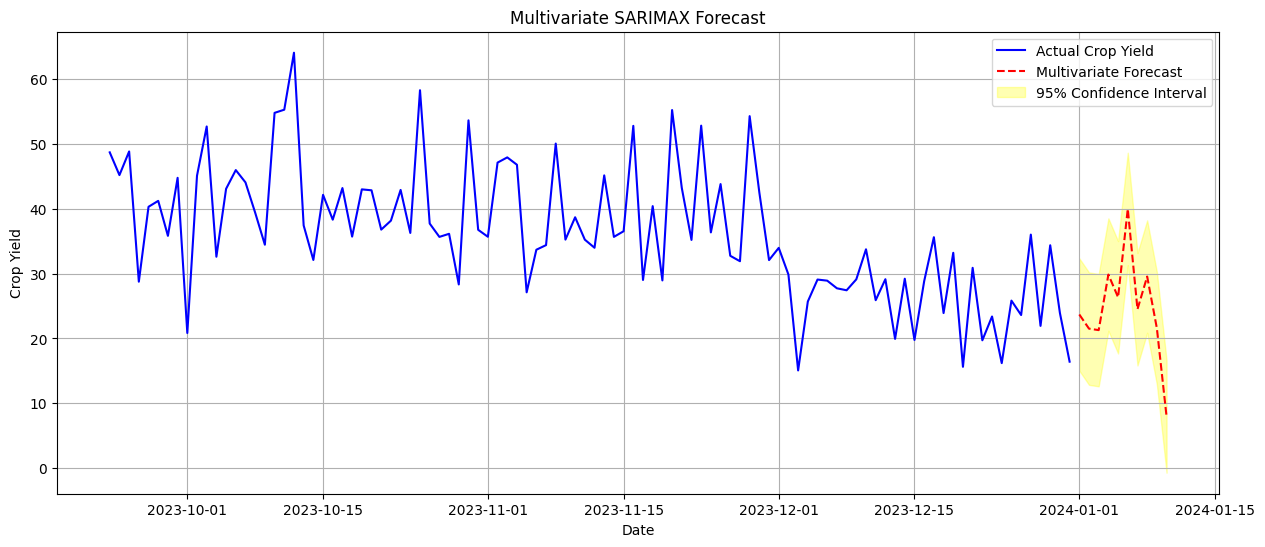

In [11]:

plt.figure(figsize=(15, 6))
plt.plot(target.index[-100:], target[-100:], label="Actual Crop Yield", color='blue')
plt.plot(forecast_mean_multi.index, forecast_mean_multi, linestyle="--", color="red", label="Multivariate Forecast")
plt.fill_between(forecast_ci_multi.index,
                 forecast_ci_multi.iloc[:, 0],
                 forecast_ci_multi.iloc[:, 1],
                 color="yellow", alpha=0.3,
                 label="95% Confidence Interval")
plt.title("Multivariate SARIMAX Forecast")
plt.xlabel("Date")
plt.ylabel("Crop Yield")
plt.grid(True)
plt.legend(loc='best')
plt.show()

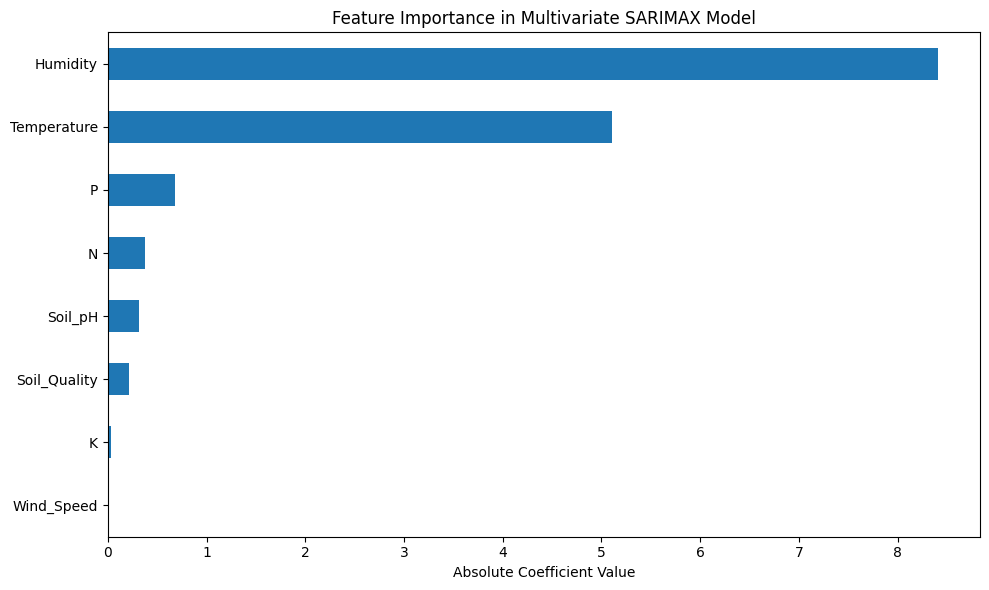

In [12]:
feature_importance = fit_multi.params.filter(like='_x')
if not feature_importance.empty:
    plt.figure(figsize=(10, 6))
    np.abs(feature_importance).sort_values().plot(kind='barh')
    plt.title('Feature Importance in Multivariate SARIMAX Model')
    plt.xlabel('Absolute Coefficient Value')
    plt.tight_layout()
    plt.show()
else:
    all_params = fit_multi.params
    exog_params = all_params[all_params.index.isin(exog.columns)]
    if not exog_params.empty:
         plt.figure(figsize=(10, 6))
         np.abs(exog_params).sort_values().plot(kind='barh')
         plt.title('Feature Importance in Multivariate SARIMAX Model')
         plt.xlabel('Absolute Coefficient Value')
         plt.tight_layout()
         plt.show()
    else: print("Could not automatically determine feature importances from model parameters.")

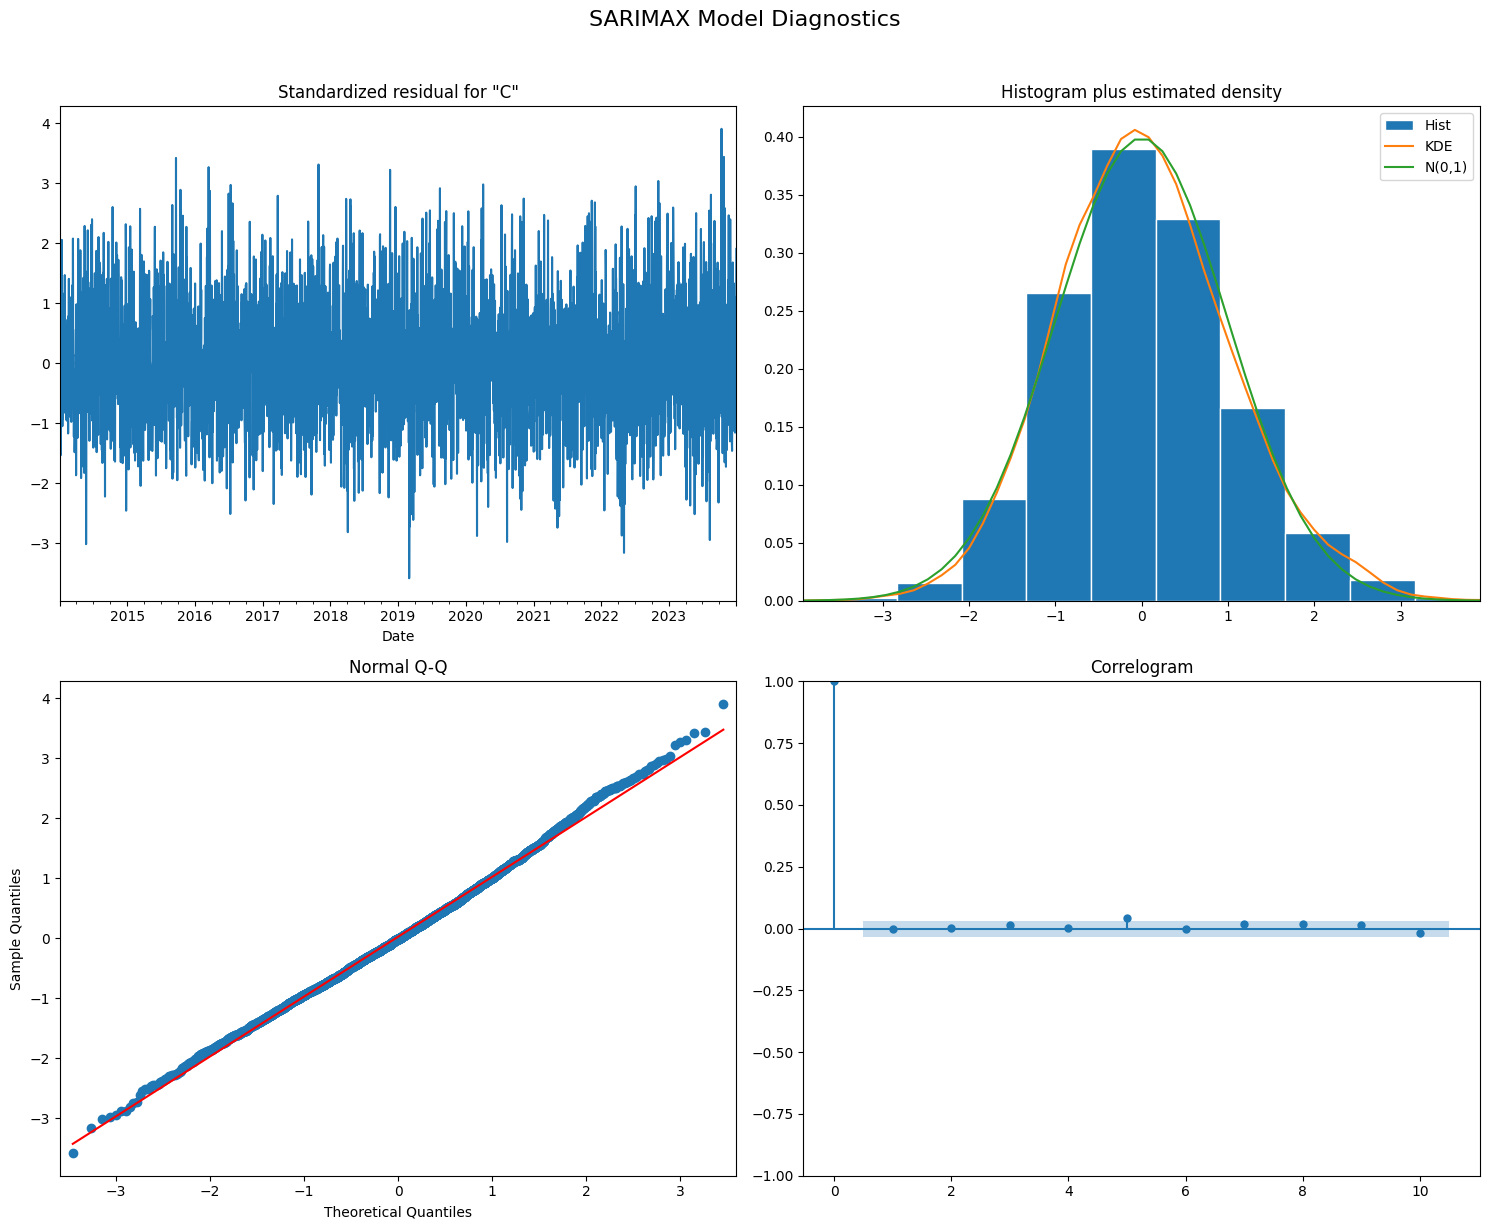

In [13]:
target = df["Crop_Yield"]
exog = df.drop(columns=["Crop_Yield"])
model_multi = SARIMAX(target, exog=exog, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
fit_multi = model_multi.fit(disp=False)
fit_multi.plot_diagnostics(figsize=(15, 12))
plt.suptitle("SARIMAX Model Diagnostics", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

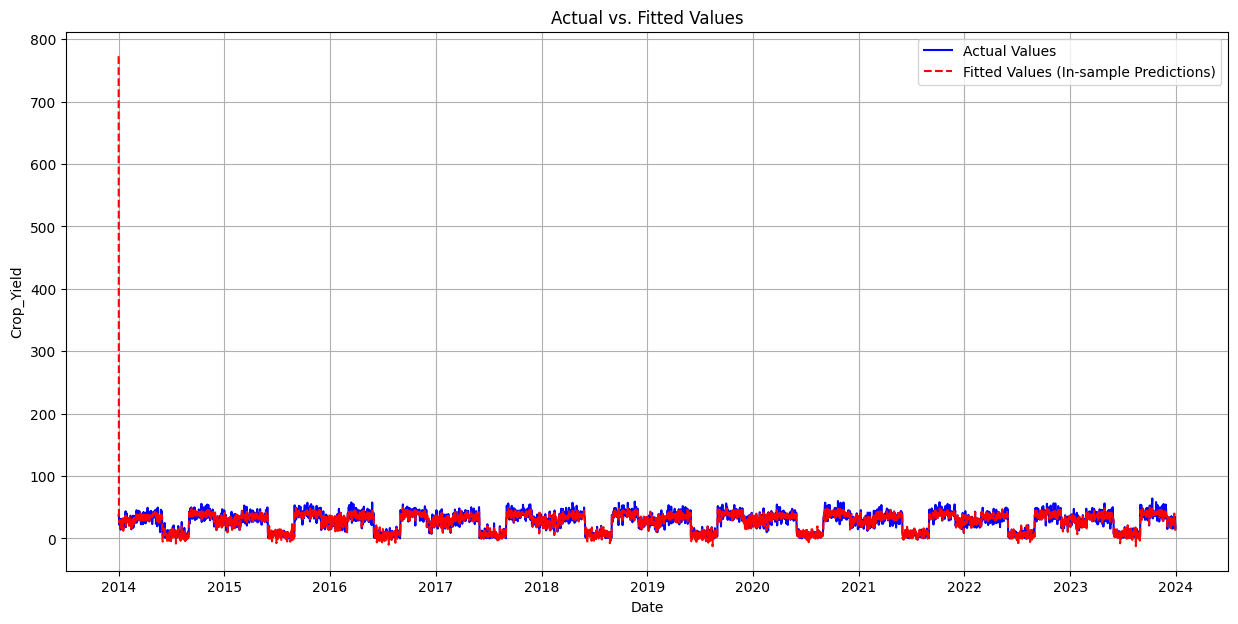

In [14]:
target = df["Crop_Yield"]
exog = df.drop(columns=["Crop_Yield"])
model = SARIMAX(target, exog=exog, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
fit = model.fit(disp=False)
fitted_values = fit.fittedvalues
plt.figure(figsize=(15, 7))
plt.plot(target.index, target, label="Actual Values", color='blue')
plt.plot(fitted_values.index, fitted_values, label="Fitted Values (In-sample Predictions)", color='red', linestyle='--')
plt.title("Actual vs. Fitted Values")
plt.xlabel("Date")
plt.ylabel("Crop_Yield")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# === Forecast function ===
def forecast_from_date(start_date, steps=7):
    start_date = pd.to_datetime(start_date)
    forecast_obj = fit_uni.get_forecast(steps=steps)
    forecast_mean = forecast_obj.predicted_mean
    forecast_ci = forecast_obj.conf_int()

    # Restrict forecast index to 7 days after entered date
    forecast_index = pd.date_range(start=start_date + pd.Timedelta(days=1), periods=steps, freq="D")
    forecast_mean.index = forecast_index
    forecast_ci.index = forecast_index

    # Display
    print(f"\nForecast from {start_date.date()} for next {steps} days:\n")
    print(forecast_mean)

    # Plot
    plt.figure(figsize=(12,5))
    plt.plot(df["Crop_Yield"], label="Observed")
    plt.plot(forecast_mean.index, forecast_mean, label="Forecast", color="orange")
    plt.fill_between(forecast_ci.index,
                     forecast_ci.iloc[:,0],
                     forecast_ci.iloc[:,1], color="lightgray", alpha=0.5)
    plt.axvline(x=start_date, color="red", linestyle="--", label="Forecast Start")
    plt.legend()
    plt.show()


In [16]:
fit_uni.save("crop_yield_sarimax.pkl")
print("Model saved successfully.")



Model saved successfully.


In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
fit_uni = SARIMAXResults.load("crop_yield_sarimax.pkl")
print("Model loaded successfully")


Model loaded successfully
